# Machine learning
**Jeu de données Engie**

In [1]:
#!pip install keras_tuner # Sur Google collab

In [2]:
import pandas as pd # Pour la gestion des données
import numpy as np # Pour les calculs mathématiques
import matplotlib.pyplot as plt # Pour les graphiques

from sklearn.preprocessing import StandardScaler # Pour la normalisation des données
from sklearn.metrics import mean_squared_error, mean_absolute_error # Pour les critères d'erreur
# https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
from sklearn.model_selection import train_test_split # Pour le découpage apprentissage/test
from sklearn.model_selection import GridSearchCV, KFold # Pour la recherche des hyperparamètres optimaux et la validation croisée
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
from sklearn.linear_model import LinearRegression # Pour la régression linéaire
from sklearn.linear_model import Ridge, RidgeCV # Pour la régression Ridge
from sklearn.linear_model import Lasso, LassoCV # Pour la régression LASSO
from sklearn.linear_model import ElasticNet, ElasticNetCV # Pour la régression Elastic Net
from sklearn.neighbors import KNeighborsRegressor # Pour les plus proches voisins
from sklearn.tree import DecisionTreeRegressor, plot_tree # Pour les arbres de régression CART
from sklearn.ensemble import RandomForestRegressor # Pour les random forests
from sklearn.ensemble import GradientBoostingRegressor # Pour le gradient boosting
from sklearn.svm import SVR # Pour les SVR

from xgboost import XGBRegressor # Pour XGBoost

import keras
from keras import models, layers, callbacks # Pour les DNN
from keras_tuner.tuners import RandomSearch # Pour les DNN (recherche des hyperparamètres optimaux)

import warnings # Pour les messages d'avertissement
from sklearn.exceptions import ConvergenceWarning # Pour les messages d'avertissement

import time # Pour les temps d'exécution

Using TensorFlow backend


Pour connaître le nombre de coeurs de sa machine :

In [3]:
import joblib
n_cores = joblib.cpu_count(only_physical_cores=True)
print(f'Nombre de coeurs (physiques): {n_cores}')

Nombre de coeurs (physiques): 12


## 1. Traitement des données

### 1.1. Importation des données

In [4]:
repert = '/Users/vincentlefieux/Dropbox/Docs_ACADEMIQUE/Data/'
#repert = '' # Sur Google collab

x = pd.read_csv(repert + 'engie_X.csv', header=0, sep=';', decimal='.')
y = pd.read_csv(repert + 'engie_Y.csv', header=0, sep=';', decimal='.')

print(x.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617386 entries, 0 to 617385
Data columns (total 78 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ID                                   617386 non-null  int64  
 1   MAC_CODE                             617386 non-null  object 
 2   Date_time                            617386 non-null  float64
 3   Pitch_angle                          617386 non-null  float64
 4   Pitch_angle_min                      617386 non-null  float64
 5   Pitch_angle_max                      617386 non-null  float64
 6   Pitch_angle_std                      617386 non-null  float64
 7   Hub_temperature                      617386 non-null  float64
 8   Hub_temperature_min                  617386 non-null  float64
 9   Hub_temperature_max                  617386 non-null  float64
 10  Hub_temperature_std                  617386 non-null  float64
 11  Generator_con

### 1.2. Analyse des données manquantes

On concatène les données pour éviter les erreurs de traitement :

In [5]:
data = pd.merge(x, y, on='ID', how='inner')
print('Dimensions :', data.shape)

Dimensions : (617386, 79)


In [6]:
missing_percentage = data.isna().mean() * 100

In [7]:
print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

Grid_voltage                     16.411451
Grid_voltage_min                 16.411451
Grid_voltage_max                 16.411451
Grid_voltage_std                 16.411451
Generator_converter_speed         1.306152
Generator_converter_speed_min     1.306152
Generator_converter_speed_max     1.306152
Generator_converter_speed_std     1.306152
Gearbox_inlet_temperature         1.306152
Gearbox_inlet_temperature_min     1.306152
Gearbox_inlet_temperature_max     1.306152
Gearbox_inlet_temperature_std     1.306152
Absolute_wind_direction_c         0.011662
Nacelle_angle_c                   0.011662
dtype: float64


In [8]:
#pd.set_option('display.max_rows', None)
#print(missing_percentage.sort_values(ascending=False))
#print(missing_percentage.sort_values(ascending=False))
#pd.reset_option('display.max_rows')

On constate que les variables `Grid_voltage`, `Grid_voltage_min`, `Grid_voltage_max` et `Grid_voltage_std` présentent beaucoup de données manquantes (environ 16%) ; on analyse ces variables pour décider de leur retrait ou de leur imputation.

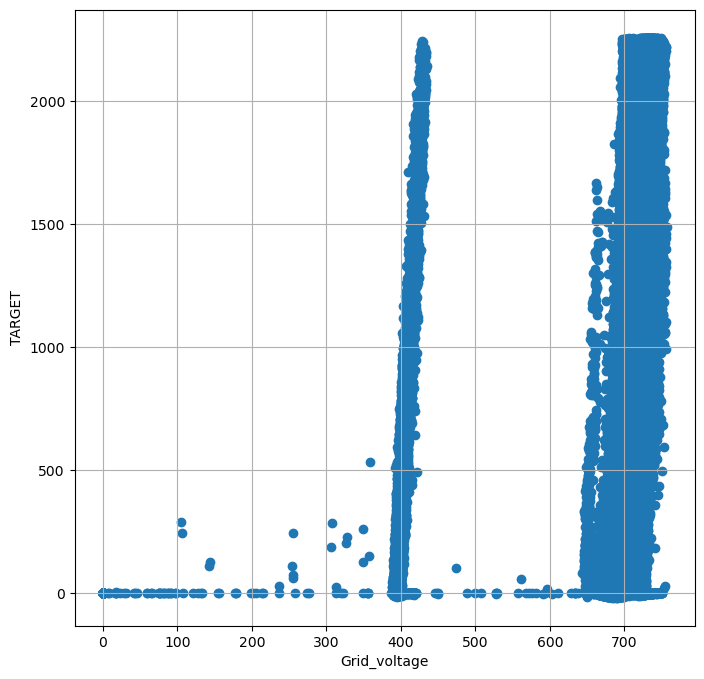

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(data['Grid_voltage'], data['TARGET'])
ax.grid()
ax.set_xlabel('Grid_voltage')
ax.set_ylabel('TARGET')
plt.show()

Cette analyse nous incite à retirer ces variables dans une première approche :

In [10]:
to_remove = data.columns[data.columns.str.startswith('Grid_voltage')]
data = data.drop(columns=to_remove)
print('Dimensions :', data.shape)

Dimensions : (617386, 75)


### 1.3. Restriction du champs d'étude

On peut remarquer que les couples de variables `Absolute_wind_direction`-`Absolute_wind_direction_c` et `Nacelle_angle`-`Nacelle_angle_c` sont quasiment identiques (seules des valeurs manquantes les séparent), on en supprime une sur deux (celle ne présentant pas de données manquantes par hypothèse, il faudrait vérifier la pertinence de cette dernière auprès du "métier") :

In [11]:
different_rows = data[['Absolute_wind_direction','Absolute_wind_direction_c']][data['Absolute_wind_direction'] != data['Absolute_wind_direction_c']]
print('Dimensions :', different_rows.shape)
different_rows.head()

Dimensions : (144, 2)


,Absolute_wind_direction,Absolute_wind_direction_c
11437,302.92999,NaN
11438,316.19000,302.92999
11439,334.54999,NaN
11440,317.09000,334.54999
11441,309.92999,NaN


In [12]:
different_rows = data[['Nacelle_angle','Nacelle_angle_c']][data['Nacelle_angle'] != data['Nacelle_angle_c']]
print('Dimensions :', different_rows.shape)
different_rows.head()

Dimensions : (96, 2)


,Nacelle_angle,Nacelle_angle_c
11437,294.23999,NaN
11438,322.78000,294.23999
11439,300.98999,NaN
11440,322.78000,300.98999
11441,322.78000,NaN


In [13]:
to_remove = ['Absolute_wind_direction_c','Nacelle_angle_c']
data = data.drop(columns=to_remove)
print('Dimensions :', data.shape)

Dimensions : (617386, 73)


On retire les observations pour lesquelles il subsiste des données manquantes :

In [14]:
data = data.dropna()
print('Dimensions :', data.shape)

Dimensions : (609322, 73)


In [15]:
data['MAC_CODE'].value_counts()

MAC_CODE
WT2    152775
WT1    152691
WT3    152237
WT4    151619
Name: count, dtype: int64

In [16]:
data = data[data['MAC_CODE'] == 'WT4']
data.shape

(151619, 73)

On observe le lien entre `TARGET` et `Rotor_speed` :

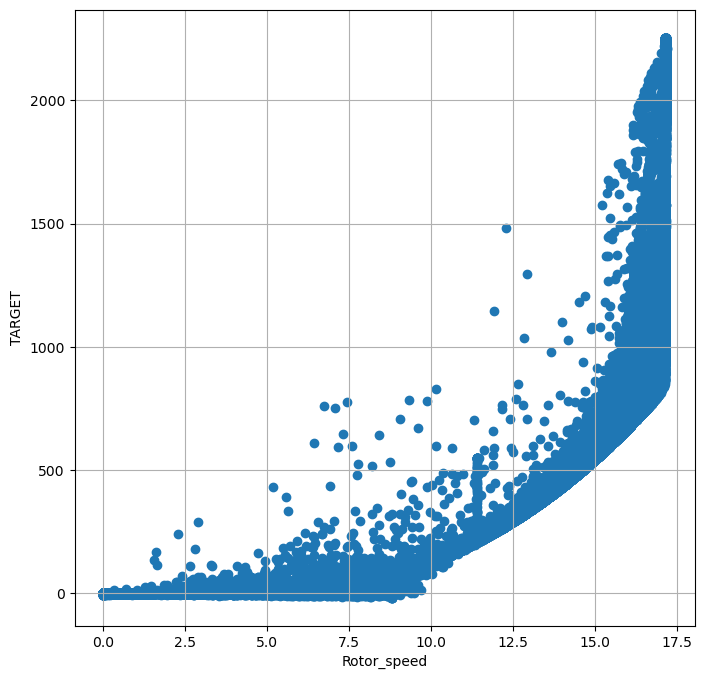

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(data['Rotor_speed'], data['TARGET'])
ax.grid()
ax.set_xlabel('Rotor_speed')
ax.set_ylabel('TARGET')
plt.show()

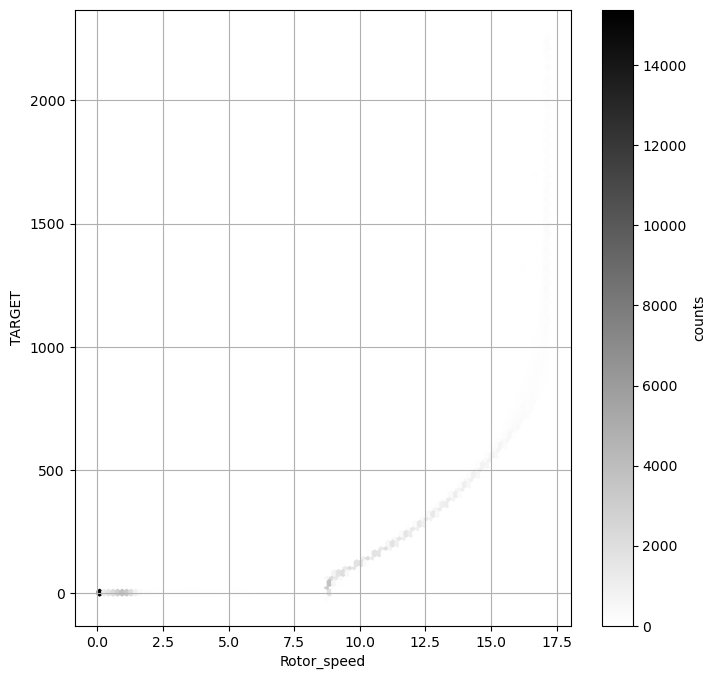

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
hb = ax.hexbin(data['Rotor_speed'], data['TARGET'], cmap='binary')
ax.grid()
ax.set_xlabel('Rotor_speed')
ax.set_ylabel('TARGET')
cb = fig.colorbar(hb, ax=ax, label='counts')
plt.show()

On retire les petites puissances (dont les négatives) selon le métier :

In [19]:
data = data[data['TARGET'] > 100]
data.shape

(91231, 73)

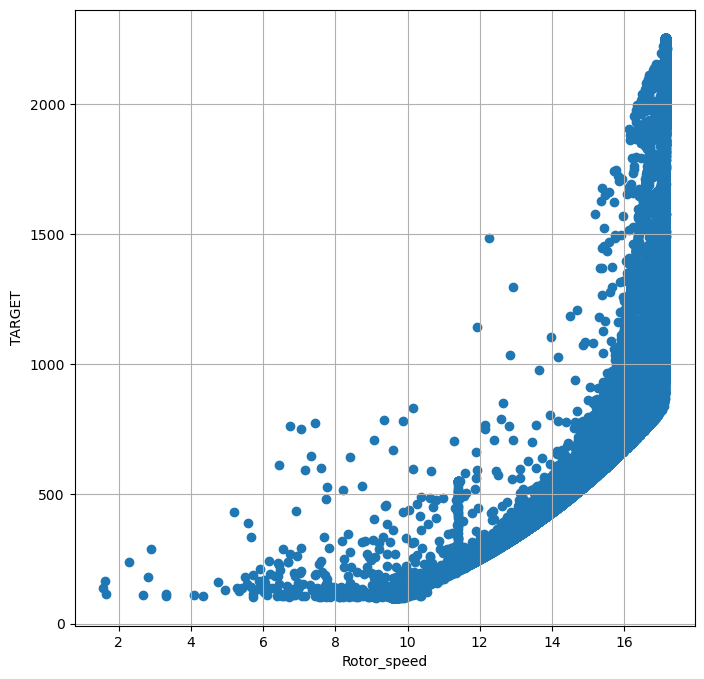

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(data['Rotor_speed'], data['TARGET'])
ax.grid()
ax.set_xlabel('Rotor_speed')
ax.set_ylabel('TARGET')
plt.show()

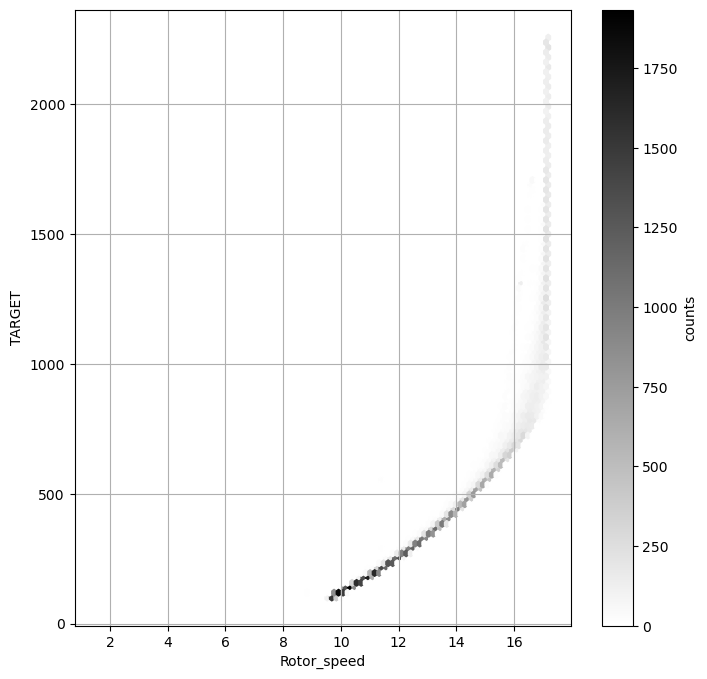

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))
hb = ax.hexbin(data['Rotor_speed'], data['TARGET'], cmap='binary')
ax.grid()
ax.set_xlabel('Rotor_speed')
ax.set_ylabel('TARGET')
cb = fig.colorbar(hb, ax=ax, label='counts')
plt.show()

In [22]:
data = data.sample(frac=0.1, random_state=1789)
data.shape

(9123, 73)

### 1.4. Création d'un jeu de données d'apprentissage et de test

In [23]:
features = list(data.columns.difference(['TARGET', 'MAC_CODE', 'Date_time']))

x = data[features]
y = data['TARGET']

In [24]:
test_portion = 1/5

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_portion, random_state=1789)

print('Dimensions x_train:', x_train.shape)
print('Dimensions y_train:', y_train.shape)
print('Dimensions x_test:', x_test.shape)
print('Dimensions y_test:', y_test.shape)

Dimensions x_train: (7298, 70)
Dimensions y_train: (7298,)
Dimensions x_test: (1825, 70)
Dimensions y_test: (1825,)


### 1.5. Normalisation des covariables

In [25]:
mean_std_normaler = StandardScaler().fit(x_train)

x_train_norm = mean_std_normaler.transform(x_train)
x_test_norm = mean_std_normaler.transform(x_test)

## 2. Modélisation

On retire ici les avertissements concernant les problème de convergence pour la lisibilité du notebook.

In [26]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

### 2.1. Régression linéaire

In [27]:
start_time = time.time()

linreg_all_model = LinearRegression()
linreg_all = linreg_all_model.fit(x_train, y_train)

In [28]:
y_test_pred_linreg_all = linreg_all.predict(x_test)

RMSE_linreg_all = np.sqrt(mean_squared_error(y_test, y_test_pred_linreg_all))
print(f'RMSE Régression linéaire complète : {RMSE_linreg_all:.2f}')

MAE_linreg_all = mean_absolute_error(y_test, y_test_pred_linreg_all) * 100
print(f'MAE Régression linéaire complète : {MAE_linreg_all:.2f}')

RMSE Régression linéaire complète : 84.76
MAE Régression linéaire complète : 5937.22


In [29]:
end_time = time.time()
execution_time_linreg_all = end_time - start_time
print(f"Temps d'exécution Régression linéaire complète : {execution_time_linreg_all:.2f} secondes")

Temps d'exécution Régression linéaire complète : 0.17 secondes


### 2.2. Régression régularisée

#### 2.2.1. Ridge

In [30]:
start_time = time.time()

In [31]:
ridge_grid = RidgeCV(alphas=np.linspace(start=1e-12, stop=100, num=100)).fit(x_train_norm, y_train)

alpha_opt = ridge_grid.alpha_
print(f'Hyperparamètre optimal : {alpha_opt:.5f}')

ridge_model = Ridge(alpha_opt)
ridge = ridge_model.fit(x_train_norm, y_train)

Hyperparamètre optimal : 1.01010


In [32]:
y_test_pred_ridge = ridge.predict(x_test_norm)

RMSE_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
print(f'RMSE Ridge : {RMSE_ridge:.2f}')

MAE_ridge = mean_absolute_error(y_test, y_test_pred_ridge) * 100
print(f'MAE Ridge : {MAE_ridge:.2f}')

RMSE Ridge : 84.22
MAE Ridge : 5955.18


In [33]:
end_time = time.time()
execution_time_ridge = end_time - start_time
print(f"Temps d'exécution Ridge : {execution_time_ridge:.2f} secondes")

Temps d'exécution Ridge : 0.31 secondes


#### 2.2.2. LASSO

In [34]:
start_time = time.time()

In [35]:
lasso_grid = LassoCV(alphas=np.linspace(start=1e-5, stop=1, num=50), max_iter=1000).fit(x_train_norm, y_train)

alpha_opt = lasso_grid.alpha_
print(f'Hyperparamètre optimal : {alpha_opt:.5f}')

lasso_model = Lasso(alpha_opt)
lasso = lasso_model.fit(x_train_norm, y_train)

Hyperparamètre optimal : 0.00001


In [36]:
y_test_pred_lasso = lasso.predict(x_test_norm)

RMSE_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
print(f'RMSE LASSO : {RMSE_lasso:.2f}')

MAE_lasso = mean_absolute_error(y_test, y_test_pred_lasso) * 100
print(f'MAE LASSO : {MAE_lasso:.2f}')

RMSE LASSO : 84.60
MAE LASSO : 5987.91


In [37]:
end_time = time.time()
execution_time_lasso = end_time - start_time
print(f"Temps d'exécution LASSO : {execution_time_lasso:.2f} secondes")

Temps d'exécution LASSO : 1.98 secondes


#### 2.2.3. Elastic Net

In [38]:
start_time = time.time()

In [39]:
elasticnet_grid = ElasticNetCV(l1_ratio=0.5, alphas=np.linspace(start=1e-10, stop=1, num=1000)).fit(x_train_norm, y_train)

alpha_opt = elasticnet_grid.alpha_
print(f'Hyperparamètre optimal : {alpha_opt:.5f}')

elasticnet_model = ElasticNet(l1_ratio=0.5, alpha=alpha_opt)
elasticnet = elasticnet_model.fit(x_train_norm, y_train)

Hyperparamètre optimal : 0.00000


In [40]:
y_test_pred_elasticnet = elasticnet.predict(x_test_norm)

RMSE_elasticnet = np.sqrt(mean_squared_error(y_test, y_test_pred_elasticnet))
print(f'RMSE Elastic Net : {RMSE_elasticnet:.2f}')

MAE_elasticnet = mean_absolute_error(y_test, y_test_pred_elasticnet) * 100
print(f'MAE Elastic Net : {MAE_elasticnet:.2f}')

RMSE Elastic Net : 84.60
MAE Elastic Net : 5987.92


In [41]:
end_time = time.time()
execution_time_elasticnet = end_time - start_time
print(f"Temps d'exécution Elastic Net : {execution_time_elasticnet:.2f} secondes")

Temps d'exécution Elastic Net : 3.06 secondes


### 2.3. Plus proches voisins

In [42]:
start_time = time.time()

In [43]:
n_folds = 10

params = {
    'n_neighbors': [2, 5, 10, 15, 20, 25]
}

knn = KNeighborsRegressor()
knn_grid = GridSearchCV(estimator=knn, param_grid=params, scoring='neg_mean_absolute_error', cv=n_folds, n_jobs=-1, verbose=1)
# n_jobs=-1 : pour utiliser tous les core disponibles
# scoring='neg_mean_squared_error' : -MSE (pour avoir un critère de performance et non d'erreur)
knn_grid.fit(x_train_norm, y_train)

Fitting 10 folds for each of 6 candidates, totalling 60 fits


GridSearchCV(cv=10, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [2, 5, 10, 15, 20, 25]},
             scoring='neg_mean_absolute_error', verbose=1)

In [44]:
print('Hyperparamètre optimal :', knn_grid.best_params_)

y_test_pred_knn = knn_grid.predict(x_test_norm)

RMSE_knn = np.sqrt(mean_squared_error(y_test, y_test_pred_knn))
print(f'RMSE Plus proches voisins : {RMSE_knn:.2f}')

MAE_knn = mean_absolute_error(y_test, y_test_pred_knn) * 100
print(f'MAE Plus proches voisins : {MAE_knn:.2f}')

Hyperparamètre optimal : {'n_neighbors': 15}
RMSE Plus proches voisins : 116.95
MAE Plus proches voisins : 7336.45


In [45]:
end_time = time.time()
execution_time_knn = end_time - start_time
print(f"Temps d'exécution Plus proches voisins : {execution_time_knn:.2f} secondes")

Temps d'exécution Plus proches voisins : 3.09 secondes


### 2.4. CART

In [46]:
start_time = time.time()

In [47]:
cart_model = DecisionTreeRegressor()
cart = cart_model.fit(x_train, y_train)

In [48]:
y_test_pred_cart = cart.predict(x_test)

RMSE_cart = np.sqrt(mean_squared_error(y_test, y_test_pred_cart))
print(f'RMSE CART : {RMSE_cart:.2f}')

MAE_cart = mean_absolute_error(y_test, y_test_pred_cart) * 100
print(f'MAE CART : {MAE_cart:.2f}')

RMSE CART : 57.72
MAE CART : 2538.79


In [49]:
end_time = time.time()
execution_time_cart = end_time - start_time
print(f"Temps d'exécution CART : {execution_time_cart:.2f} secondes")

Temps d'exécution CART : 0.32 secondes


### 2.5. Random forest

In [50]:
start_time = time.time()

In [51]:
n_folds = 10

#param_grid = {
#    'max_depth': [80, 90, 100],
#    'min_samples_leaf': [3, 4, 5],
#    'min_samples_split': [8, 10, 12],
#    'n_estimators': [200, 300, 400, 500]
#}

params = {
    'n_estimators': [200, 300, 400]
}

rf = RandomForestRegressor()
rf_grid = GridSearchCV(estimator=rf, param_grid=params, scoring='neg_mean_absolute_error', cv=n_folds, n_jobs=-1, verbose=0)
# n_jobs=-1 : pour utiliser tous les core disponibles
# scoring='neg_mean_absolute_error' : -MAE (pour avoir un critère de performance et non d'erreur)
rf_grid.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'n_estimators': [200, 300, 400]},
             scoring='neg_mean_absolute_error')

In [52]:
print('Hyperparamètre optimal :', rf_grid.best_params_)

y_test_pred_rf = rf_grid.predict(x_test)

RMSE_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
print(f'RMSE Random forest : {RMSE_rf:.2f}')

MAE_rf = mean_absolute_error(y_test, y_test_pred_rf) * 100
print(f'MAE Random forest : {MAE_rf:.2f}')

Hyperparamètre optimal : {'n_estimators': 400}
RMSE Random forest : 41.00
MAE Random forest : 1766.42


In [53]:
end_time = time.time()
execution_time_rf = end_time - start_time
print(f"Temps d'exécution Random forest : {execution_time_rf:.2f} secondes")

Temps d'exécution Random forest : 251.65 secondes


### 2.6. Gradient boosting

#### 2.6.1. $L^1$-boosting

In [54]:
start_time = time.time()

In [55]:
n_folds = 10

params = {
    'n_estimators': [100, 150, 200, 250, 300, 350],
    'learning_rate': [0.02, 0.03, 0.04, 0.05, 0.1]
}

gb_l1 = GradientBoostingRegressor(loss='absolute_error')

gb_l1_grid = GridSearchCV(estimator=gb_l1, param_grid=params, scoring='neg_mean_squared_error', cv=n_folds, n_jobs=-1, verbose=1)
gb_l1_grid.fit(x_train, y_train)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


GridSearchCV(cv=10, estimator=GradientBoostingRegressor(loss='absolute_error'),
             n_jobs=-1,
             param_grid={'learning_rate': [0.02, 0.03, 0.04, 0.05, 0.1],
                         'n_estimators': [100, 150, 200, 250, 300, 350]},
             scoring='neg_mean_squared_error', verbose=1)

In [56]:
print('Hyperparamètres optimaux:', gb_l1_grid.best_params_)

y_test_pred_gb_l1 = gb_l1_grid.predict(x_test)

RMSE_gb_l1 = np.sqrt(mean_squared_error(y_test, y_test_pred_gb_l1))
print(f'RMSE L1-boosting : {RMSE_gb_l1:.2f}')

MAE_gb_l1 = mean_absolute_error(y_test, y_test_pred_gb_l1) * 100
print(f'MAE L1-boosting : {MAE_gb_l1:.2f}')

Hyperparamètres optimaux: {'learning_rate': 0.1, 'n_estimators': 350}
RMSE L1-boosting : 48.25
MAE L1-boosting : 2187.92


In [57]:
end_time = time.time()
execution_time_gb_l1 = end_time - start_time
print(f"Temps d'exécution L1-boosting : {execution_time_gb_l1:.2f} secondes")

Temps d'exécution L1-boosting : 442.84 secondes


#### 2.6.2. $L^2$-boosting

In [58]:
start_time = time.time()

In [59]:
n_folds = 10

params = {
    'n_estimators': [100, 150, 200, 250, 300, 350],
    'learning_rate': [0.02, 0.03, 0.04, 0.05, 0.1]
}

gb_l2 = GradientBoostingRegressor(loss='squared_error')

gb_l2_grid = GridSearchCV(estimator=gb_l2, param_grid=params, scoring='neg_mean_squared_error', cv=n_folds, n_jobs=-1, verbose=1)
# n_jobs=-1 : pour utiliser tous les core disponibles
# scoring='neg_mean_squared_error' : -MSE
gb_l2_grid.fit(x_train, y_train)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


GridSearchCV(cv=10, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.02, 0.03, 0.04, 0.05, 0.1],
                         'n_estimators': [100, 150, 200, 250, 300, 350]},
             scoring='neg_mean_squared_error', verbose=1)

In [60]:
print('Hyperparamètres optimaux:', gb_l2_grid.best_params_)

y_test_pred_gb_l2 = gb_l2_grid.predict(x_test)

RMSE_gb_l2 = np.sqrt(mean_squared_error(y_test, y_test_pred_gb_l2))
print(f'RMSE L2-boosting : {RMSE_gb_l2:.2f}')

MAE_gb_l2 = mean_absolute_error(y_test, y_test_pred_gb_l2) * 100
print(f'MAE L2-boosting : {MAE_gb_l2:.2f}')

Hyperparamètres optimaux: {'learning_rate': 0.1, 'n_estimators': 350}
RMSE L2-boosting : 36.98
MAE L2-boosting : 1832.75


In [61]:
end_time = time.time()
execution_time_gb_l2 = end_time - start_time
print(f"Temps d'exécution L2-boosting : {execution_time_gb_l2:.2f} secondes")

Temps d'exécution L2-boosting : 437.49 secondes


#### 2.6.3. XGBoost

In [62]:
start_time = time.time()

In [63]:
n_folds = 10

params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb_l2 = XGBRegressor(objective='reg:squarederror')

xgb_l2_grid = GridSearchCV(estimator=xgb_l2, param_grid=params, scoring='neg_mean_squared_error', cv=n_folds, n_jobs=-1, verbose=1)
# n_jobs=-1 : pour utiliser tous les core disponibles
# scoring='neg_mean_squared_error' : -MSE
xgb_l2_grid.fit(x_train_norm, y_train)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None,...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error', verbose=1)

In [64]:
print('Hyperparamètres optimaux:', xgb_l2_grid.best_params_)

y_test_pred_xgb_l2 = xgb_l2_grid.predict(x_test_norm)

RMSE_xgb_l2 = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_l2))
print(f'RMSE XGBoost L2 : {RMSE_xgb_l2:.2f}')

MAE_xgb_l2 = mean_absolute_error(y_test, y_test_pred_xgb_l2) * 100
print(f'MAE XGBoost L2 : {MAE_xgb_l2:.2f}')

Hyperparamètres optimaux: {'learning_rate': 0.05, 'n_estimators': 200}
RMSE XGBoost L2 : 38.90
MAE XGBoost L2 : 1709.95


In [65]:
end_time = time.time()
execution_time_xgb_l2 = end_time - start_time
print(f"Temps d'exécution XGBoost L2: {execution_time_xgb_l2:.2f} secondes")

Temps d'exécution XGBoost L2: 9.75 secondes


### 4.7. SVR (RBF)

In [66]:
start_time = time.time()

In [67]:
n_folds = 10

#params = {
#    'gamma': np.logspace(start=-2, stop=2, num=10),
#    'C': [1, 10, 100, 1000, 10000]
#}

params = {
    'gamma': np.logspace(start=-2, stop=2, num=5),
    'C': np.linspace(start=10, stop=1000, num=5)
}

svr_rbf = SVR(kernel='rbf')

svr_rbf_grid = GridSearchCV(estimator=svr_rbf, param_grid=params, scoring='neg_mean_squared_error', cv=n_folds, n_jobs=-1, verbose=1)
# n_jobs=-1 : pour utiliser tous les core disponibles
# scoring='neg_mean_squared_error' : -MSE
svr_rbf_grid.fit(x_train_norm, y_train)

Fitting 10 folds for each of 25 candidates, totalling 250 fits


GridSearchCV(cv=10, estimator=SVR(), n_jobs=-1,
             param_grid={'C': array([  10. ,  257.5,  505. ,  752.5, 1000. ]),
                         'gamma': array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])},
             scoring='neg_mean_squared_error', verbose=1)

In [68]:
print('Hyperparamètres optimaux:', svr_rbf_grid.best_params_)

y_test_pred_svr_rbf = svr_rbf_grid.predict(x_test_norm)

RMSE_svr_rbf = np.sqrt(mean_squared_error(y_test, y_test_pred_svr_rbf))
print(f'RMSE SVR (RBF) : {RMSE_svr_rbf:.2f}')

MAE_svr_rbf = mean_absolute_error(y_test, y_test_pred_svr_rbf) * 100
print(f'MAE SVR (RBF) : {MAE_svr_rbf:.2f}')

Hyperparamètres optimaux: {'C': 1000.0, 'gamma': 0.01}
RMSE SVR (RBF) : 60.91
MAE SVR (RBF) : 3037.66


In [69]:
end_time = time.time()
execution_time_svr_rbf = end_time - start_time
print(f"Temps d'exécution SVR (RBF) : {execution_time_svr_rbf:.2f} secondes")

Temps d'exécution SVR (RBF) : 163.66 secondes


### 4.8. DNN

In [70]:
start_time = time.time()

In [71]:
dim_outputs = 1

def build_model(hp):
    model = keras.Sequential()
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(units = hp.Int('Units_' + str(i+1),
                                              min_value = 32,
                                              max_value = 512,
                                              step      = 32),
                               activation = 'relu',
                               name       = 'Layer_' + str(i+1)))
        model.add(layers.Dropout(rate=0.2))
    model.add(layers.Dense(dim_outputs, activation='linear', name='Output_layer'))
    model.compile(
        #optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        optimizer = 'Adam',
        loss      = 'mean_squared_error',
        metrics   = ['mae'])
    return model

In [72]:
nb_trials = 50

dnn = RandomSearch(
    build_model,
    objective            = 'val_loss',
    max_trials           = nb_trials,
    executions_per_trial = 3,
    directory            = 'Project',
    project_name         = 'engie')

In [73]:
stop_early = callbacks.EarlyStopping(monitor              = 'val_loss',
                                     mode                 = 'min',
                                     patience             = 10,
                                     restore_best_weights = True)

dnn.search(x_train_norm,
           y_train,
           epochs           = 500,
           validation_split = 0.2,
           callbacks        = [stop_early])

Trial 50 Complete [00h 00m 54s]
val_loss: 3420.5291341145835

Best val_loss So Far: 2881.8994954427085
Total elapsed time: 00h 53m 38s


In [74]:
dnn.results_summary()

Results summary
Results in Project/Boston
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 18 summary
Hyperparameters:
num_layers: 3
Units_1: 320
Units_2: 256
Units_3: 384
Score: 2881.8994954427085

Trial 28 summary
Hyperparameters:
num_layers: 2
Units_1: 416
Units_2: 384
Units_3: 512
Score: 2894.6212565104165

Trial 33 summary
Hyperparameters:
num_layers: 2
Units_1: 160
Units_2: 288
Units_3: 288
Score: 2916.1068522135415

Trial 11 summary
Hyperparameters:
num_layers: 3
Units_1: 320
Units_2: 448
Units_3: 448
Score: 2920.6456705729165

Trial 23 summary
Hyperparameters:
num_layers: 3
Units_1: 288
Units_2: 384
Units_3: 288
Score: 2925.7451985677085

Trial 05 summary
Hyperparameters:
num_layers: 2
Units_1: 160
Units_2: 160
Score: 2929.4126790364585

Trial 02 summary
Hyperparameters:
num_layers: 2
Units_1: 480
Units_2: 288
Score: 2949.331787109375

Trial 04 summary
Hyperparameters:
num_layers: 2
Units_1: 160
Units_2: 480
Score: 2956.6200358072915

Trial 17 summary
H

In [75]:
dnn_grid = dnn.get_best_models(num_models=1)[0]

In [76]:
y_test_pred_dnn = dnn_grid.predict(x_test_norm)

RMSE_dnn = np.sqrt(mean_squared_error(y_test, y_test_pred_dnn))
print(f'RMSE DNN : {RMSE_dnn:.2f}')

MAE_dnn = mean_absolute_error(y_test, y_test_pred_dnn) * 100
print(f'MAE DNN : {MAE_dnn:.2f}')

58/58 [==============================] - 0s 621us/step
RMSE DNN : 52.13
MAE DNN : 2899.71


In [77]:
end_time = time.time()
execution_time_dnn = end_time - start_time
print(f"Temps d'exécution DNN : {execution_time_dnn:.2f} secondes")

Temps d'exécution DNN : 3218.09 secondes


### 4.9. Synthèse

In [78]:
RMSE_model = {}

RMSE_model['Régression linéaire complète'] = RMSE_linreg_all
RMSE_model['Ridge'] = RMSE_ridge
RMSE_model['LASSO'] = RMSE_lasso
RMSE_model['Elastic Net'] = RMSE_elasticnet
RMSE_model['Plus proches voisins'] = RMSE_knn
RMSE_model['CART'] = RMSE_cart
RMSE_model['Random forest'] = RMSE_rf
RMSE_model['L1-boosting'] = RMSE_gb_l1
RMSE_model['L2-boosting'] = RMSE_gb_l2
RMSE_model['XGBoost L2'] = RMSE_xgb_l2
RMSE_model['SVR (RBF)'] = RMSE_svr_rbf
RMSE_model['DNN'] = RMSE_dnn

RMSE_model

{'Régression linéaire complète': 84.7582826019204,
 'Ridge': 84.2213780510186,
 'LASSO': 84.6042165346275,
 'Elastic Net': 84.60421476871934,
 'Plus proches voisins': 116.94779195555671,
 'CART': 57.71801198064176,
 'Random forest': 41.001564782618544,
 'L1-boosting': 48.251137170404604,
 'L2-boosting': 36.97772828122919,
 'XGBoost L2': 38.89571030821312,
 'SVR (RBF)': 60.91190294524348,
 'DNN': 52.13277047120199}

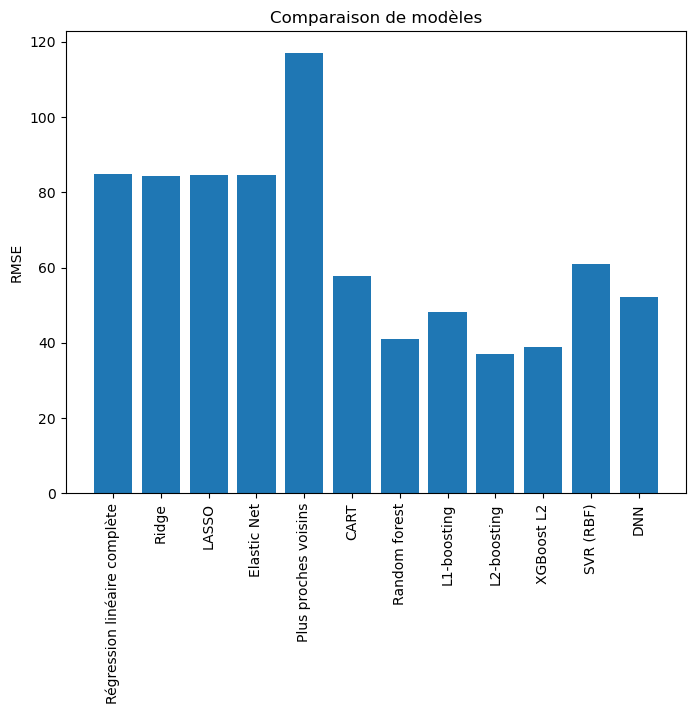

In [79]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(RMSE_model.keys(), RMSE_model.values())
#ax.grid()
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('RMSE')

plt.title('Comparaison de modèles')
plt.show()

In [80]:
MAE_model = {}

MAE_model['Régression linéaire complète'] = MAE_linreg_all
MAE_model['Ridge'] = MAE_ridge
MAE_model['LASSO'] = MAE_lasso
MAE_model['Elastic Net'] = MAE_elasticnet
MAE_model['Plus proches voisins'] = MAE_knn
MAE_model['CART'] = MAE_cart
MAE_model['Random forest'] = MAE_rf
MAE_model['L1-boosting'] = MAE_gb_l1
MAE_model['L2-boosting'] = MAE_gb_l2
MAE_model['XGBoost L2'] = MAE_xgb_l2
MAE_model['SVR (RBF)'] = MAE_svr_rbf
MAE_model['DNN'] = MAE_dnn

MAE_model

{'Régression linéaire complète': 5937.216801469934,
 'Ridge': 5955.177053274745,
 'LASSO': 5987.914442568197,
 'Elastic Net': 5987.91792574743,
 'Plus proches voisins': 7336.447489629225,
 'CART': 2538.792675205479,
 'Random forest': 1766.4191047272595,
 'L1-boosting': 2187.9230541452594,
 'L2-boosting': 1832.7463624566342,
 'XGBoost L2': 1709.9536016167804,
 'SVR (RBF)': 3037.662407827415,
 'DNN': 2899.712003342679}

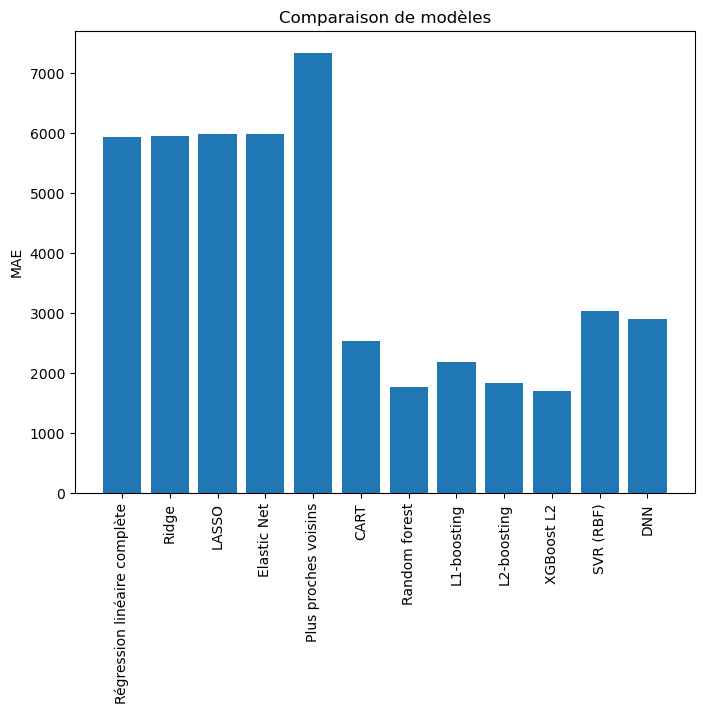

In [81]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(MAE_model.keys(), MAE_model.values())
#ax.grid()
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('MAE')

plt.title('Comparaison de modèles')
plt.show()

In [82]:
Execution_time_model = {}

Execution_time_model['Régression linéaire complète'] = execution_time_linreg_all
Execution_time_model['Ridge'] = execution_time_ridge
Execution_time_model['LASSO'] = execution_time_lasso
Execution_time_model['Elastic Net'] = execution_time_elasticnet
Execution_time_model['Plus proches voisins'] = execution_time_knn
Execution_time_model['CART'] = execution_time_cart
Execution_time_model['Random forest'] = execution_time_rf
Execution_time_model['L1-boosting'] = execution_time_gb_l1
Execution_time_model['L2-boosting'] = execution_time_gb_l2
Execution_time_model['XGBoost L2'] = execution_time_xgb_l2
Execution_time_model['SVR (RBF)'] = execution_time_svr_rbf
Execution_time_model['DNN'] = execution_time_dnn

Execution_time_model

{'Régression linéaire complète': 0.17264294624328613,
 'Ridge': 0.3067800998687744,
 'LASSO': 1.979919672012329,
 'Elastic Net': 3.0626659393310547,
 'Plus proches voisins': 3.0872719287872314,
 'CART': 0.3215210437774658,
 'Random forest': 251.6491768360138,
 'L1-boosting': 442.83824276924133,
 'L2-boosting': 437.48550176620483,
 'XGBoost L2': 9.745850801467896,
 'SVR (RBF)': 163.65943813323975,
 'DNN': 3218.0865869522095}

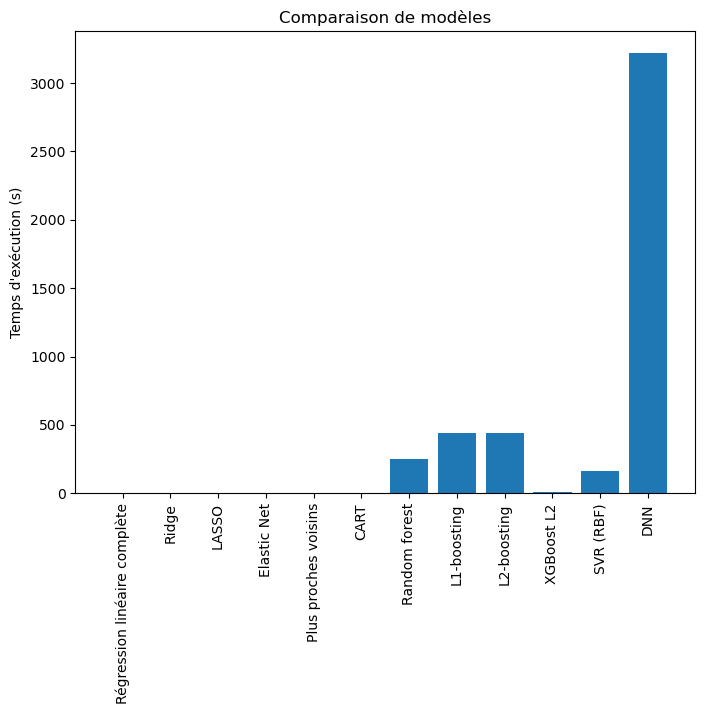

In [83]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(Execution_time_model.keys(), Execution_time_model.values())
#ax.grid()
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel("Temps d'exécution (s)")

plt.title('Comparaison de modèles')
plt.show()